In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Άσκηση - Μετασχηματισμός Fourier Διακριτού Χρόνου

Ας προσπαθήσουμε να προσομοιώσουμε το μετασχ. Fourier διακριτού χρόνου σε διάφορα σήματα στην ````Python````. Ξέρουμε στη θεωρία, λοιπόν, πώς να υπολογίζουμε ένα μετασχ. Fourier διακριτού χρόνου. Όμως όπως γνωρίζετε, ο μετασχ. Fourier είναι $\textit{συνεχής}$ συνάρτηση του $\omega$, άρα ορίζεται σε άπειρα σημεία του άξονα $\omega$. Αυτό αποτελεί ένα μικρό πρόβλημα για την αναπαράστασή του στην ````Python````, το οποίο καλείστε να ξεπεράσετε σε αυτήν την άσκηση.. 😃 Η άσκηση αυτή απαιτεί την κατανόησή των όσων αναφέρονται, καθώς ο κώδικας που καλείστε να γράψετε είναι ελάχιστος.

Ας θυμηθούμε τον ορισμό:

\begin{equation}
X(e^{j\omega}) = \sum_{n=-\infty}^{+\infty}x[n]e^{-j\omega n}
\end{equation}

Θα χρειαστεί να δειγματοληπτήσουμε τις συναρτήσεις $e^{j\omega n}$ ως προς τη συνεχή μεταβλητή $\omega$, αφού είναι αδύνατο να έχουμε στον υπολογιστή μας άπειρες τιμές της συχνότητας (οσες δηλ. απαιτούνται στο διάστημα $(-\pi, \pi]$). Αυτό σημαίνει ότι θα υπολογίσουμε το μετασχ. Fourier μόνο σε $\textit{ορισμένες}$ συχνότητες, και όχι σε κάθε $\omega \in (-\pi, \pi]$. Επίσης, πρακτικά το παραπάνω άθροισμα θα είναι πεπερασμένο (ξανά, δεν μπορούμε να αθροίσουμε από $n=-\infty$ ως $+\infty$), κι έστω ότι ο υπολογισμός χρησιμοποιεί $N$ σημεία του σήματος στο χρόνο. Με βάση αυτά μπορούμε να προσεγγίσουμε το μετασχ. Fourier ως

\begin{equation}
X(e^{j\omega_k n}) \approx \sum_{n=<N>}x[n]e^{-j\omega_k n}
\end{equation}

με το συμβολισμό $<N>$ να δηλώνει ότι αθροίζουμε $N$ συνεχόμενα δείγματα στο χρόνο, π.χ. από $n=-10$ ως $10$, και το συμβολισμό $\omega_k$ να δηλώνει μερικές τιμές της συχνότητας $\omega$ στο διάστημα $(-\pi, \pi]$. Έστω οτι διαμερίζουμε το διάστημα $(-\pi, \pi]$ ομοιόμορφα ανά $\Delta \omega$ - θα δείτε παρακάτω πως γίνεται αυτό - και προκύπτουν $2K+1$ τιμές συχνότητας στο διάστημα αυτό: χονδρικά, $K$ από αυτές θα βρίσκονται στο διάστημα $(-\pi, 0)$, άλλες $K$ θα βρίσκονται στο διάστημα $(0, \pi]$, και μια θα βρίσκεται κοντά στο $\omega = 0$. 

Δείτε έναν απλό και διαισθητικό τρόπο να υλοποιήσουμε το άθροισμα αυτό, με τον παρακάτω κώδικα, για ένα πολύ γνωστό σας σήμα:

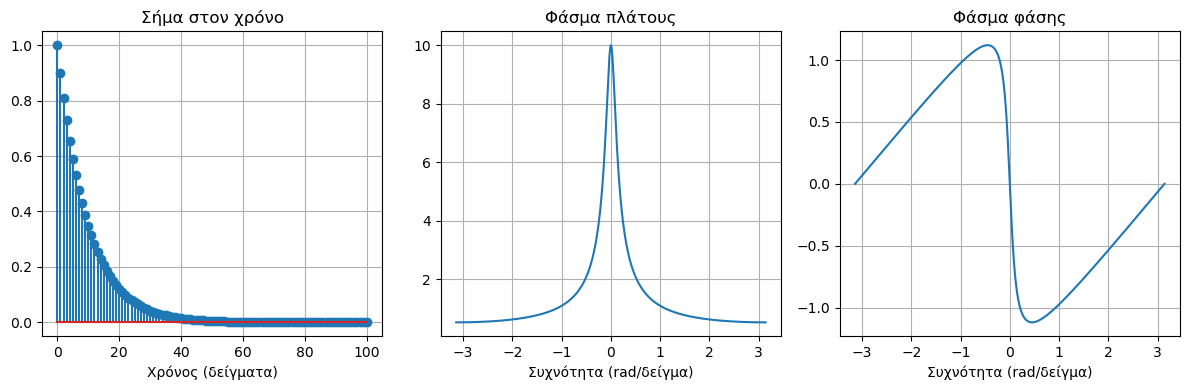

In [2]:
# Παράμετροι
a = 0.9                              # Για παράδειγμα, a = 0.9
n = np.arange(0, 101)                # Διάνυσμα διακριτού χρόνου: 0..100
x = a**n                             # x[n] = a^n * u[n] (u[n]=1 για n>=0)

dw = 2*np.pi/600                       # Βήμα συχνότητας
w = np.arange(-np.pi, np.pi + dw, dw)  # Διάνυσμα δειγμάτων συχνότητας (περιλαμβάνει το άκρο)
X = np.zeros_like(w, dtype=np.complex128)  # (κενό) διάνυσμα DTFT

L = len(n)                            # Δίνει L = 101

# Βρόχος - Άθροιση για όλα τα χρονικά δείγματα n
for i in range(L):
    X += x[i] * np.exp(-1j * w * n[i])

# Σχεδίαση σήματος, φάσματος πλάτους και φάσης του DTFT
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.stem(n, x)
plt.grid(True)
plt.title('Σήμα στον χρόνο')
plt.xlabel('Χρόνος (δείγματα)')

plt.subplot(1, 3, 2)
plt.plot(w, np.abs(X))
plt.grid(True)
plt.title('Φάσμα πλάτους')
plt.xlabel('Συχνότητα (rad/δείγμα)')

plt.subplot(1, 3, 3)
plt.plot(w, np.angle(X))
plt.grid(True)
plt.title('Φάσμα φάσης')
plt.xlabel('Συχνότητα (rad/δείγμα)')

plt.tight_layout()

Ο τρόπος αυτός είναι αρκετά διαισθητικός αλλά όχι ο βέλτιστος δυνατός - για την ακρίβεια, είναι ιδιαίτερα αργός σε περιβάλλοντα όπως η ````Python````, λόγω του βρόχου επανάληψης.

Καλείστε να συμπληρώσετε την παρακάτω δοσμένη συνάρτηση ````myDTFT```` η οποία υπολογίζει το μετασχ. Fourier διακριτού χρόνου με διαφορετικό τρόπο από τον παραπάνω, και την οποία θα χρησιμοποιήσετε παρακάτω.


In [3]:
def myDTFT(x, n):
    """
    Υπολογίζει τον DTFT ενός σήματος διακριτού χρόνου.

    Ορίσματα:
        x : 1D τύπου πίνακα, τα δείγματα του σήματος (μήκος N)
        n : 1D τύπου πίνακα, οι αντίστοιχοι χρονικοί δείκτες (μήκος N)

    Επιστρέφει:
        X : 1D μιγαδικό np.ndarray μήκους 601 (δείγματα DTFT)
        w : 1D np.ndarray μήκους 601 (πλέγμα συχνοτήτων, ακτίνια/δείγμα)
    """
    x = np.asarray(x)
    n = np.asarray(n)

    if x.shape != n.shape:
        raise ValueError("x and n must have the same shape")

    # Πλέγμα συχνοτήτων
    w = np.linspace(-np.pi, np.pi, 601)  # περιλαμβάνει τα άκρα

    # Πίνακας E: διάσταση (N, 601)
    E = np.exp(-1j * n[:, None] * w[None, :])

    # DTFT - χρήση των x και E
    X = x.astype(np.complex128) @ E # Χρήση του τελεστή @

    return X, w


με $x$ και $n$ το διάνυσμα που αντιπροσωπεύει το σήμα διακριτού χρόνου και το διάνυσμα με τις τιμές διακριτού χρόνου που αντιστοιχούν στο σήμα, αντίστοιχα. 

### Επεξήγηση: 

Τα διανύσματα $X$ και $w$ θα περιέχουν το μετασχ. Fourier διακριτού χρόνου και τον άξονα των συχνοτήτων $\omega_k$ αντίστοιχα, δηλ. τις τιμές συχνότητες στις οποίες υπολογίσαμε το μετασχ. Fourier. Η υλοποίησή της γίνεται πιο γρήγορα και αποδοτικά με χρήση πινάκων. Για το τελευταίο, προσέξτε ότι ο μετασχ. Fourier διακριτού χρόνου $X$ μπορεί να γραφεί ως το γινόμενο 

\begin{equation}
X = x^TE
\end{equation}

των πινάκων

\begin{equation}
x_{N\times 1} = \begin{bmatrix}
\vdots \\
x[-1] \\
x[0] \\
x[1] \\
\vdots 
\end{bmatrix}
\end{equation}

που περιέχει τις τιμές του σήματος διακριτού χρόνου διάρκειας $N$ δειγμάτων και 

\begin{equation}
E_{N \times (2K+1)} = \begin{bmatrix}
\vert & \vert & \vert & \vert & \vert & \vert & \vert \\
\vert & \vert & \vert & \vert & \vert & \vert & \vert \\
e^{-j\omega_{-K} n} & e^{-j\omega_{-(K-1)} n} & \cdots & e^{-j\omega_0 n} & \cdots & e^{-j\omega_{K-1} n} & e^{-j\omega_K n} \\
\vert & \vert & \vert & \vert & \vert & \vert & \vert \\
\vert & \vert & \vert & \vert & \vert & \vert & \vert \\
\end{bmatrix}
\end{equation}
τον περίφημο πίνακα Fourier, με $\omega_i$, $i=-K,\cdots,K$ την $i-$οστή τιμή της συχνότητας που έχει προκύψει από τη διαμέριση. Το σύμβολο $^T$ δηλώνει το ανάστροφο διάνυσμα.

Παρατηρήστε ότι σε κάθε στήλη του πίνακα $E$ υπάρχει ένα μιγαδικό εκθετικό σήμα μιας $\textit{συγκεκριμένης}$ συχνότητας, για τις χρονικές τιμές $n$ που έχουμε ορίσει. Έτσι, θα έχουμε $2K+1$ στήλες, όσες και οι διαφορετικές συχνότητες που διαμερίζουμε το διάστημα $(-\pi, \pi]$. Αντίθετα, θα έχουμε $N$ γραμμές, αφού η μεταβλητή $n$ δηλώνει το χρόνο και έχουμε $N$ τέτοιες τιμές. Τέλος, παρατηρήστε ότι το γινόμενο $x^T E$ θα πρέπει να σας δώσει ένα μιγαδικό διάνυσμα διάστασης $1\times (2K+1)$, σύμφωνα με τους κανόνες της Γραμμικής Άλγεβρας. Κάθε τιμή του διανύσματος αυτού θα είναι η τιμή του μετασχ. Fourier διακριτού χρόνου για κάθε μια από τις $\omega_i$ συχνότητες!

---

Όταν γράψετε σωστά τη συνάρτηση, εκτελέστε τον κώδικα που ακολουθεί για να την ελέγξετε, που υπολογίζει το φάσμα πλάτους και φάσης του σήματος
\begin{equation}
x[n] = (1/2)^n u[n]
\end{equation}
του οποίου γνωρίζετε το μετασχ. Fourier από τη θεωρία. 

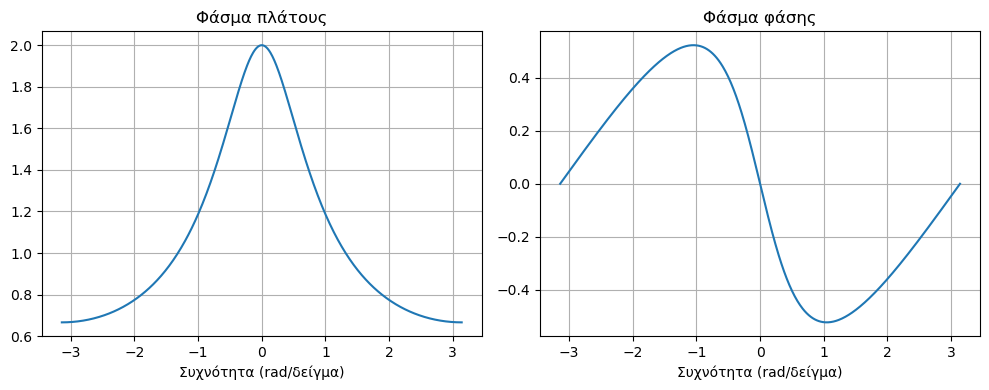

In [4]:
# Έλεγχος της myDTFT...
N = 1000                 # Άνω χρονικό όριο
n = np.arange(N + 1)     # Διάνυσμα χρόνου 0..N
x = (1/2)**n             # Σήμα: (1/2)^n u[n]

X, w = myDTFT(x, n)      # Κλήση της συνάρτησης DTFT

# Σχεδίαση φάσματος πλάτους και φάσης
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(w, np.abs(X))
plt.grid(True)
plt.title('Φάσμα πλάτους')
plt.xlabel('Συχνότητα (rad/δείγμα)')

plt.subplot(1, 2, 2)
plt.plot(w, np.angle(X))
plt.grid(True)
plt.title('Φάσμα φάσης')
plt.xlabel('Συχνότητα (rad/δείγμα)')

plt.tight_layout()

Αν όλα πάνε καλά, θα πάρετε την εικόνα του Σχήματος.

<p align="center">
  <img src="./files/outputmagphase.png" alt="Centered plot" width="800">
</p>

---


Τώρα ας υλοποιήσουμε την αντίστροφη σχέση, δηλ. τον αντίστροφο μετασχ. Fourier διακριτού χρόνου. Όπως ξέρετε, ο τελευταίος δίνεται ως

\begin{equation}
x[n] = \frac{1}{2\pi}\int_{-\pi}^{\pi}X(e^{j\omega})e^{j\omega n}d\omega
\end{equation}

και δοθέντος ενός μετασχ. Fourier $X(e^{j\omega})$, μας συνθέτει το σήμα διακριτού χρόνου $x[n]$ αθροίζοντας (ολοκληρώνοντας) μιγαδικά εκθετικά σήματα συχνότητας $\omega \in (-\pi, \pi]$ με συντελεστή $X(e^{j\omega})$.

Παρατηρήστε ότι εδώ έχουμε ένα ολοκλήρωμα αντί για ένα άθροισμα. Το ολοκλήρωμα γίνεται πάνω σε μια συνεχή μεταβλητή $d\omega$, άρα πρέπει να κάνουμε ξανά τις υποθέσεις που κάναμε στο προηγούμενο ερώτημα. Η προσέγγιση αυτή ονομάζεται $\textit{άθροισμα Riemann}$, και πρακτικά μας λέει ότι ένα τέτοιο ολοκλήρωμα μπορεί να προσεγγιστεί ως

\begin{equation}
x[n] = \frac{1}{2\pi}\lim_{\Delta\omega \to 0}\sum_{k=1}^L X(e^{j\Delta \omega_k})e^{j\Delta \omega_k n}\Delta \omega 
\end{equation}

Δείτε τις ομοιότητες των Σχέσεων. Ο δείκτης $k$ απλά αριθμεί τις διαφορετικές συχνότητες $\omega_k$ που χρησιμοποιούμε. Μπορούμε να υλοποιήσουμε το ολοκλήρωμα του αντίστροφου μετασχ. Fourier για το ίδιο παράδειγμα με προηγουμένως μέσω του αθροίσματος Riemann ως:

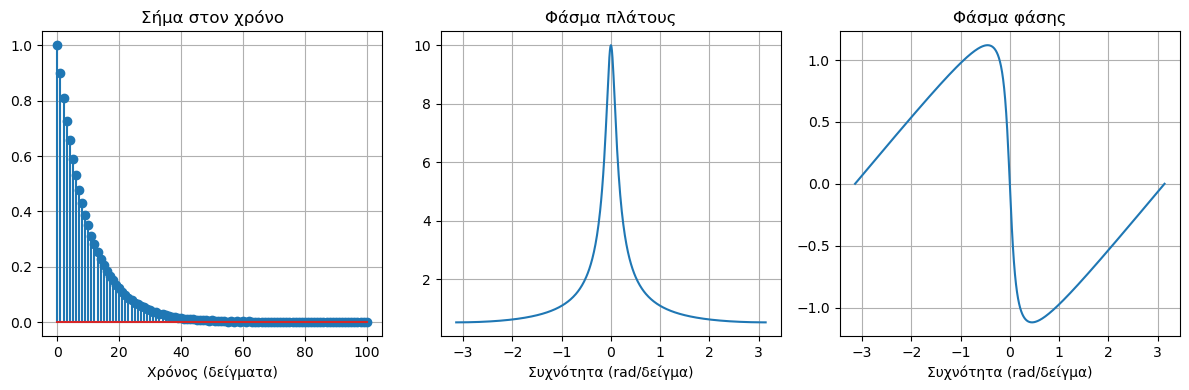

In [5]:
# Παράμετροι
a = 0.9                            # Για παράδειγμα
n = np.arange(0, 101)              # Διάνυσμα χρόνου 0..100

dw = 2*np.pi/600                     # Βήμα συχνότητας
w = np.linspace(-np.pi, np.pi, 601)  # Διάνυσμα δειγμάτων συχνότητας (περιλαμβάνει τα άκρα)
X = 1.0 / (1 - a * np.exp(-1j * w))  # Διάνυσμα DTFT

L = len(w)                           # 601
xsynth = np.zeros_like(n, dtype=np.complex128)  # κενό σήμα στο πεδίο του χρόνου

# Βρόχος - Άθροιση για όλες τις συχνότητες w
for i in range(L):                 
    xsynth += (dw/(2*np.pi)) * X[i] * np.exp(1j * w[i] * n)

# Σχεδίαση σήματος, φάσματος πλάτους και φάσης του DTFT
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.stem(n, np.real(xsynth))
#plt.stem(n, a**n)
plt.grid(True)
plt.title('Σήμα στον χρόνο')
plt.xlabel('Χρόνος (δείγματα)')

plt.subplot(1, 3, 2)
plt.plot(w, np.abs(X))
plt.grid(True)
plt.title('Φάσμα πλάτους')
plt.xlabel('Συχνότητα (rad/δείγμα)')

plt.subplot(1, 3, 3)
plt.plot(w, np.angle(X))
plt.grid(True)
plt.title('Φάσμα φάσης')
plt.xlabel('Συχνότητα (rad/δείγμα)')

plt.tight_layout()

Καλείστε να συμπληρώσετε τη δοσμένη συνάρτηση ````myiDTFT```` η οποία υπολογίζει τον αντίστρ. μετασχ. Fourier διακριτού χρόνου, την οποία θα χρησιμοποιήσετε παρακάτω.

In [6]:
def myiDTFT(X, w, n):
    """
    Αντίστροφος DTFT (αριθμητικά) μέσω αθροίσματος Riemann ως προς w.

    Ορίσματα:
        X : 1D μιγαδικός πίνακας μήκους M (δείγματα DTFT)
        w : 1D πραγματικός πίνακας μήκους M (ακτίνια/δείγμα), θεωρείται ομοιόμορφο
        n : 1D πίνακας int/float μήκους N (χρονικοί δείκτες)

    Επιστρέφει:
        x : 1D μιγαδικός πίνακας μήκους N (σήμα στο πεδίο του χρόνου)
    """
    X = np.asarray(X, dtype=np.complex128)
    w = np.asarray(w, dtype=float)
    n = np.asarray(n)

    if X.shape != w.shape:
        raise ValueError("X and w must have the same shape")

    # Βήμα συχνότητας (θεωρείται ομοιόμορφο)
    if len(w) < 2:
        raise ValueError("w must have at least two points")
    
    dw = w[1] - w[0]

    # Ο πίνακας Einv έχει διάσταση (M, N)
    Einv = np.exp(1j * w[:, None] * n[None, :])

    # x = (Δw / 2π) * X * Einv   (το X είναι 1xM, το Einv είναι MxN -> 1xN)
    x = (dw / (2 * np.pi)) * (X @ Einv)   # Χρήση του τελεστή @

    return x



με $X$, $w$, και $n$ το διάνυσμα που αντιπροσωπεύει το μετασχ. Fourier του σήματος διακριτού χρόνου, το διάνυσμα με τις τιμές συχνότητας που ο τελευταίος έχει υπολογιστεί, και το διάνυσμα του διακριτού χρόνου, αντίστοιχα. Το διάνυσμα $x$ θα περιέχει το σήμα διακριτού χρόνου $x[n]$.


### Επεξήγηση: 

Η παραπάνω υλοποίησή της γίνεται πιο γρήγορα και αποδοτικά ξανά με χρήση πινάκων, όπως προηγουμένως. Αυτή τη φορά, προσέξτε ότι ο αντίστροφος μετασχ. Fourier διακριτού χρόνου $x$ μπορεί να γραφεί ως το γινόμενο 

\begin{equation}
x = \frac{\Delta \omega}{2\pi}X^TE_{inv}

\end{equation}

των πινάκων

\begin{equation}
X_{M\times 1} = \begin{bmatrix}
\vdots \\
X(e^{-j\omega_i}) \\
\vdots \\
X(e^{j0}) \\
\vdots \\
X(e^{j\omega_i})\\
\vdots 
\end{bmatrix}
\end{equation}

που περιέχει τις τιμές του μετασχ.Fourier διάρκειας $M$ δειγμάτων και 

\begin{equation}
E_{{inv}_{M \times N}} = \begin{bmatrix}
\rule[.5ex]{2.5ex}{0.5pt}\  & \rule[.5ex]{2.5ex}{0.5pt}\   & e^{j\omega_{-K} n} & \rule[.5ex]{2.5ex}{0.5pt}\   & \rule[.5ex]{2.5ex}{0.5pt}\  \\
\rule[.5ex]{2.5ex}{0.5pt}\   & \rule[.5ex]{2.5ex}{0.5pt}\  & e^{j\omega_{-(K-1)} n} & \rule[.5ex]{2.5ex}{0.5pt}\  & \rule[.5ex]{2.5ex}{0.5pt}\  \\
 & & \vdots & & \\
\rule[.5ex]{2.5ex}{0.5pt}\  & \rule[.5ex]{2.5ex}{0.5pt}\  & e^{j\omega_{K-1} n} & \rule[.5ex]{2.5ex}{0.5pt}\   & \rule[.5ex]{2.5ex}{0.5pt}\  \\
\rule[.5ex]{2.5ex}{0.5pt}\  & \rule[.5ex]{2.5ex}{0.5pt}\  & e^{j\omega_{K} n} & \rule[.5ex]{2.5ex}{0.5pt}\  & \rule[.5ex]{2.5ex}{0.5pt}\  \\
\end{bmatrix}
\end{equation}

τον περίφημο πίνακα αντίστροφου Fourier, με $\omega_i$, $i=-K,\cdots,K$ την $i-$οστή τιμή της συχνότητας που έχετε. 



Παρατηρήστε ότι σε κάθε γραμμή του πίνακα $E^{inv}$ υπάρχει ένα μιγαδικό εκθετικό σήμα μιας $\textit{συγκεκριμένης}$ συχνότητας, για τις χρονικές τιμές $n$ που έχουμε ορίσει. Έτσι, θα έχουμε $M$ γραμμές, όσες και οι διαφορετικές συχνότητες που διαμερίζουμε το διάστημα $(-\pi, \pi]$ (αυτές που αριθμήσαμε ως $2K+1$ στο προηγουμενο ερωτημα). Αντίθετα, θα έχουμε $N$ στήλες, αφού η μεταβλητή $n$ δηλώνει το χρόνο και έχουμε $N$ τέτοιες τιμές. Τέλος, παρατηρήστε ότι το γινόμενο $X^T E^{inv}$ θα πρέπει να σας δώσει ένα (θεωρητικά, πραγματικό) διάνυσμα διάστασης $1\times N$, σύμφωνα με τους κανόνες της Γραμμικής Άλγεβρας. Κάθε τιμή του διανύσματος αυτού θα είναι η τιμή του σήματος $x[n]$ στο χρόνο για τις αντίστοιχες τιμές του διανύσματος $n$! \smiley


---

Όταν γράψετε σωστά τη συνάρτηση, εκτελέστε τον παρακάτω κώδικα για την ελέγξετε. Ο κώδικας αυτός υπολογίζει το σήμα στο χρόνο
\begin{equation}
x[n] = (1/2)^n u[n]
\end{equation}
μέσω του αντίστροφου μετασχ. Fourier για $20$ δείγματα. 

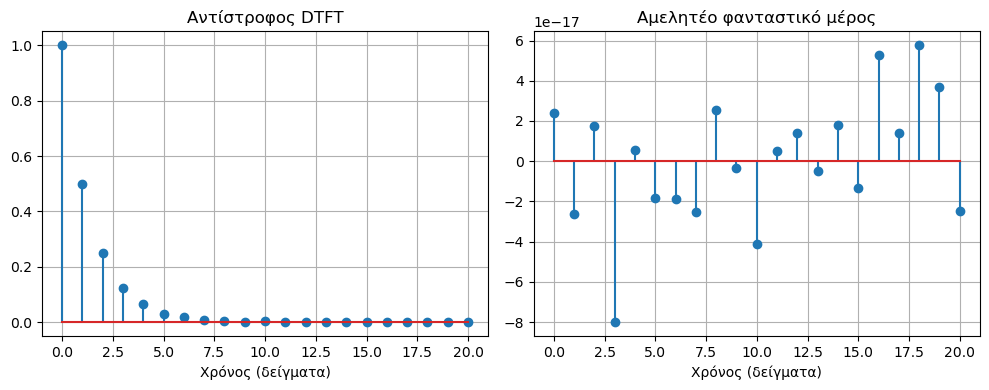

In [7]:
# Έλεγχος της myiDTFT...
dw = 2*np.pi/600                     # Βήμα συχνοτικής ανάλυσης
w = np.linspace(-np.pi, np.pi, 601)  # Διάνυσμα συχνοτήτων
n = np.arange(21)                    # Διάνυσμα χρόνου 0..20
X = 1.0 / (1 - 0.5*np.exp(-1j*w))    # DTFT του (1/2)^n u[n]

x = myiDTFT(X, w, n)                 # Κλήση του αντίστροφου DTFT

# Σχεδίαση αποτελεσμάτων
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
markerline, stemlines, baseline = plt.stem(n, np.real(x))
plt.grid(True)
plt.title('Αντίστροφος DTFT')
plt.xlabel('Χρόνος (δείγματα)')

plt.subplot(1, 2, 2)
markerline, stemlines, baseline = plt.stem(n, np.imag(x))
plt.grid(True)
plt.title('Αμελητέο φανταστικό μέρος')
plt.xlabel('Χρόνος (δείγματα)')

plt.tight_layout()


Αν όλα πάνε καλά, θα πάρετε την εικόνα του Σχήματος.


<p align="center">
  <img src="./files/outputtime.png" alt="Centered plot" width="800">
</p>


Παρατηρήστε ότι παρ' όλο που το σήμα μας στο χρόνο είναι πραγματικό, λόγω μικρών αριθμητικών σφαλμάτων υπάρχει και ένα φανταστικό μέρος στο σήμα $x[n]$ που υπολογίζουμε - το οποίο φυσικά είναι αμελητέο (της τάξης του $10^{-17}$).

---


$\textbf{Ως εδώ λοιπόν}$, απλά πρέπει να βεβαιωθείτε ότι οι δυο συναρτήσεις ````myDTFT, myiDTFT```` δουλεύουν σωστά, συμπληρώνοντας τις δυο γραμμές που λείπουν (μια γραμμή σε κάθε αρχείο) και εκτελώντας τον κώδικα ελέγχου για την καθεμιά.

## Ζητούμενα:

α. Γράψτε παρακάτω κώδικα ````Python```` που υπολογίζει το φάσμα πλάτους και φάσης για τα παρακάτω σήματα

1. $x[n] = (-1/4)^n u[n]$
2. $x[n] = \delta[n-3]$
3. $x[n] = 2^n u[-n]$

με χρήση της συνάρτησης ````myDTFT````.

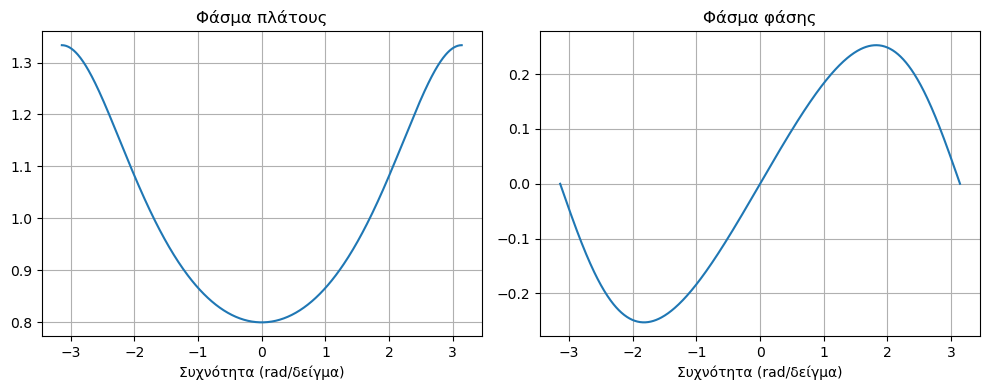

In [8]:
# ΕΙΣΑΓΩΓΗ ΚΩΔΙΚΑ ΕΔΩ

# Χρήση της myDTFT

# 1.
N = 1000                 # Άνω χρονικό όριο
n = np.arange(N + 1)     # Διάνυσμα χρόνου 0..N
x = (-1/4)**n             # Σήμα: (-1/4)^n u[n]

X, w = myDTFT(x, n)      # Κλήση της συνάρτησης DTFT

# Σχεδίαση φάσματος πλάτους και φάσης
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(w, np.abs(X))
plt.grid(True)
plt.title('Φάσμα πλάτους')
plt.xlabel('Συχνότητα (rad/δείγμα)')

plt.subplot(1, 2, 2)
plt.plot(w, np.angle(X))
plt.grid(True)
plt.title('Φάσμα φάσης')
plt.xlabel('Συχνότητα (rad/δείγμα)')

plt.tight_layout()

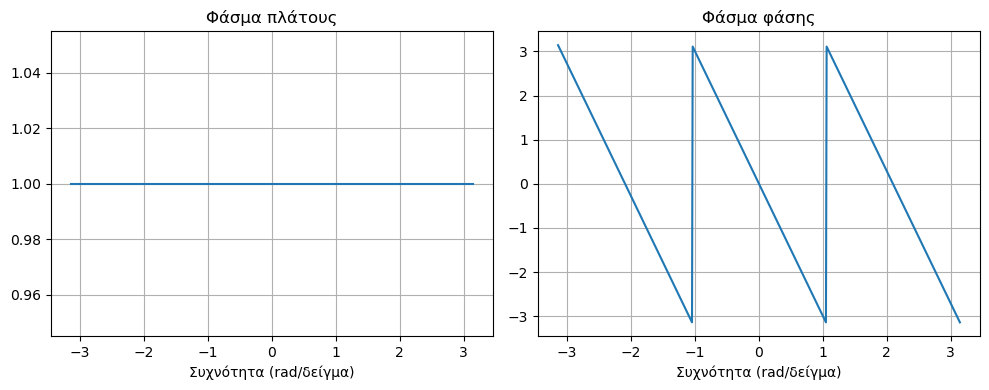

In [9]:
# 2.
N = 1000                 # Άνω χρονικό όριο
n = np.arange(N + 1)     # Διάνυσμα χρόνου 0..N
k = 3                    # δείκτης όπου τοποθετείται το 1 (με αρίθμηση από το 0)
x = np.zeros(len(n), dtype=int)
x[k] = 1

X, w = myDTFT(x, n)      # Κλήση της συνάρτησης DTFT

# Σχεδίαση φάσματος πλάτους και φάσης
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(w, np.abs(X))
plt.grid(True)
plt.title('Φάσμα πλάτους')
plt.xlabel('Συχνότητα (rad/δείγμα)')

plt.subplot(1, 2, 2)
plt.plot(w, np.angle(X))
plt.grid(True)
plt.title('Φάσμα φάσης')
plt.xlabel('Συχνότητα (rad/δείγμα)')

plt.tight_layout()

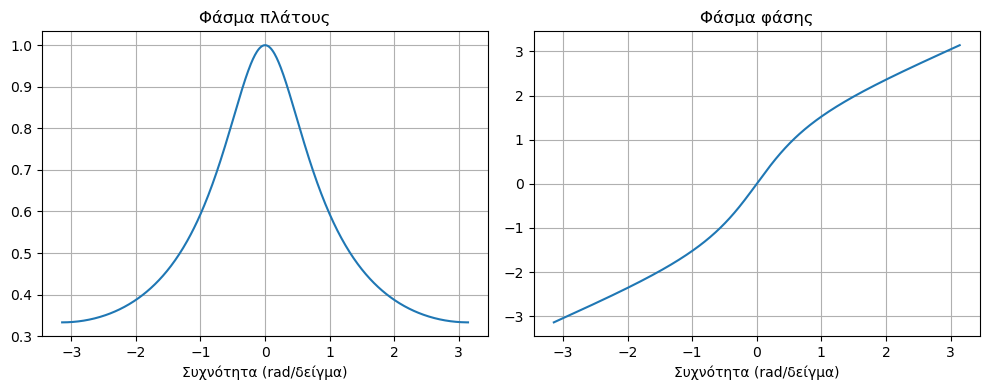

In [10]:
# 3.
N = 1000                  # Άνω χρονικό όριο
n = np.arange(-N, 0, 1)   # Διάνυσμα χρόνου -N..-1
x = np.float_power(2, n)  # Σήμα: (2)^n u[-n]

X, w = myDTFT(x, n)      # Κλήση της συνάρτησης DTFT

# Σχεδίαση φάσματος πλάτους και φάσης
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(w, np.abs(X))
plt.grid(True)
plt.title('Φάσμα πλάτους')
plt.xlabel('Συχνότητα (rad/δείγμα)')

plt.subplot(1, 2, 2)
plt.plot(w, np.angle(X))
plt.grid(True)
plt.title('Φάσμα φάσης')
plt.xlabel('Συχνότητα (rad/δείγμα)')

plt.tight_layout()

Αν όλα πάνε καλά, θα πάρετε τα παρακάτω σχήματα:

<p align="center">
  <img src="./files/dftout.png" alt="Centered plot" width="800">
</p>

β. Έστω οι μετασχ. Fourier των προηγούμενων σημάτων

1. $\displaystyle X(e^{j\omega}) = \frac{1}{1 + \frac{1}{4}e^{-j\omega}}$
2. $\displaystyle X(e^{j\omega}) = e^{-j3\omega}$
3. $\displaystyle X(e^{j\omega}) = \frac{1}{1 - \frac{1}{2}e^{j\omega}}$

Γράψτε κώδικα ````Python```` που υπολογίζει και τυπώνει τους αντίστροφους μετασχ. Fourier (δηλ. το σήμα στο χρόνο, με πραγματικό και σχεδόν μηδενικό φανταστικό μέρος) των μετασχηματισμών παραπάνω με χρήση της συνάρτησης ````myiDTFT````.

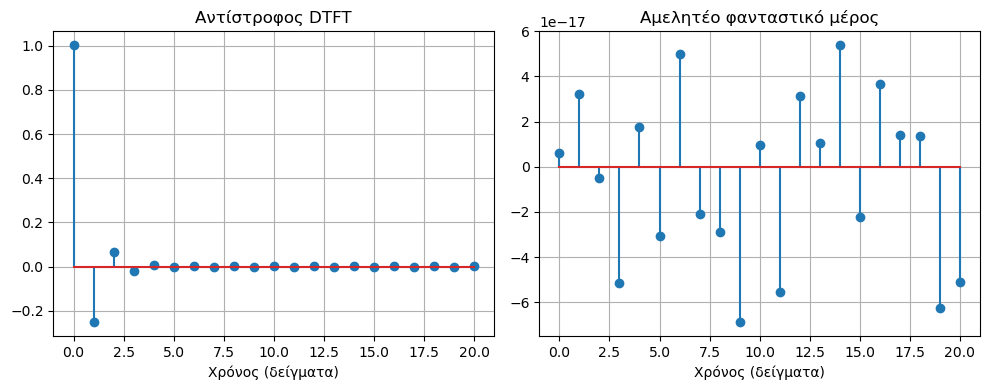

In [11]:
# ΕΙΣΑΓΩΓΗ ΚΩΔΙΚΑ ΕΔΩ

# Χρήση της myiDTFT

# 1.
dw = 2*np.pi/600                     # Βήμα συχνοτικής ανάλυσης
w = np.linspace(-np.pi, np.pi, 601)  # Διάνυσμα συχνοτήτων
n = np.arange(21)                    # Διάνυσμα χρόνου 0..20
X = 1.0 / (1 + (1/4)*np.exp(-1j*w))    # DTFT του (-1/4)^n u[n]

x = myiDTFT(X, w, n)                 # Κλήση του αντίστροφου DTFT

# Σχεδίαση αποτελεσμάτων
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
markerline, stemlines, baseline = plt.stem(n, np.real(x))
plt.grid(True)
plt.title('Αντίστροφος DTFT')
plt.xlabel('Χρόνος (δείγματα)')

plt.subplot(1, 2, 2)
markerline, stemlines, baseline = plt.stem(n, np.imag(x))
plt.grid(True)
plt.title('Αμελητέο φανταστικό μέρος')
plt.xlabel('Χρόνος (δείγματα)')

plt.tight_layout()

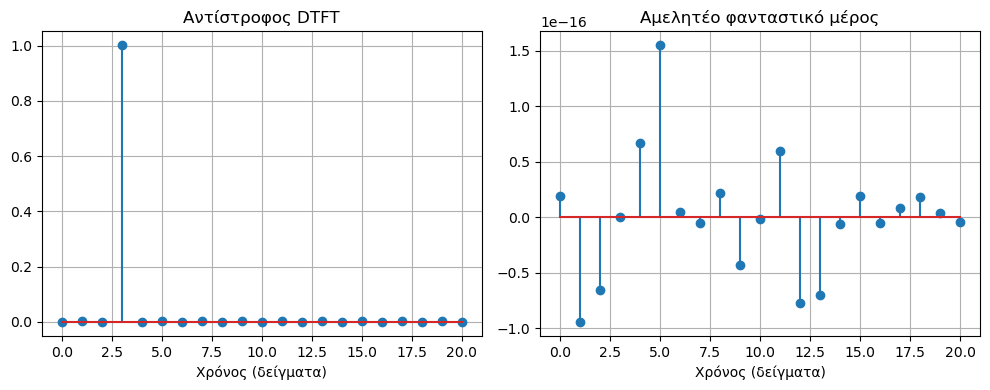

In [12]:
# 2.
dw = 2*np.pi/600                     # Βήμα συχνοτικής ανάλυσης
w = np.linspace(-np.pi, np.pi, 601)  # Διάνυσμα συχνοτήτων
n = np.arange(21)                    # Διάνυσμα χρόνου 0..20
X = np.exp(-1j*3*w)                  # DTFT του δ[n-3]

x = myiDTFT(X, w, n)                 # Κλήση του αντίστροφου DTFT

# Σχεδίαση αποτελεσμάτων
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
markerline, stemlines, baseline = plt.stem(n, np.real(x))
plt.grid(True)
plt.title('Αντίστροφος DTFT')
plt.xlabel('Χρόνος (δείγματα)')

plt.subplot(1, 2, 2)
markerline, stemlines, baseline = plt.stem(n, np.imag(x))
plt.grid(True)
plt.title('Αμελητέο φανταστικό μέρος')
plt.xlabel('Χρόνος (δείγματα)')

plt.tight_layout()

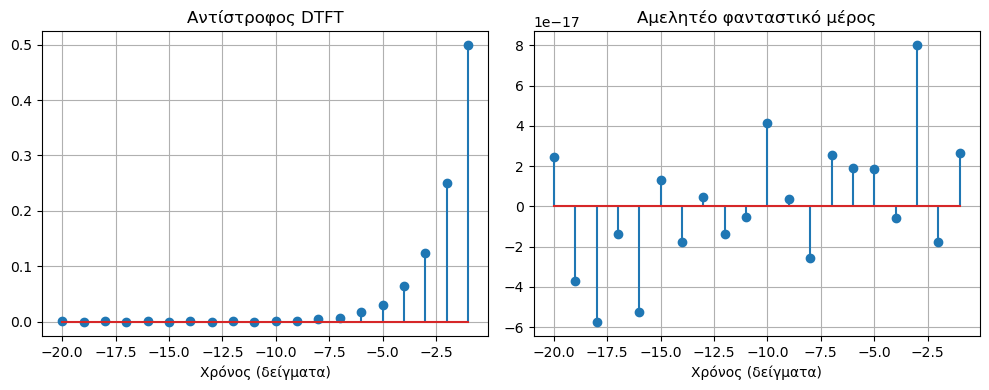

In [13]:
# 3.
dw = 2*np.pi/600                     # Βήμα συχνοτικής ανάλυσης
w = np.linspace(-np.pi, np.pi, 601)  # Διάνυσμα συχνοτήτων
n = np.arange(-20, 0, 1)                    # Διάνυσμα χρόνου -20..-1
X = 1.0 / (1 - (1/2)*np.exp(1j*w))    # DTFT του (1/4)^(-n) u[-n]

x = myiDTFT(X, w, n)                 # Κλήση του αντίστροφου DTFT

# Σχεδίαση αποτελεσμάτων
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
markerline, stemlines, baseline = plt.stem(n, np.real(x))
plt.grid(True)
plt.title('Αντίστροφος DTFT')
plt.xlabel('Χρόνος (δείγματα)')

plt.subplot(1, 2, 2)
markerline, stemlines, baseline = plt.stem(n, np.imag(x))
plt.grid(True)
plt.title('Αμελητέο φανταστικό μέρος')
plt.xlabel('Χρόνος (δείγματα)')

plt.tight_layout()

Αν όλα πάνε καλά, θα πάρετε τα παρακάτω σχήματα:

<p align="center">
  <img src="./files/idtftout.png" alt="Centered plot" width="800">
</p>

----
----